In [137]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [138]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/paultimothymooney
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/datasets/paultimothymooney/chest-x

In [139]:
import os
import numpy as np
import pandas as pd
import pathlib
import imageio

In [140]:
base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/"

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir=base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

val_normal_dir= base_dir+'val/NORMAL/'
val_pnrumonia_dir= base_dir+'val/PNEUMONIA/'

train_pn = [train_pneumonia_dir+"{}".format(i) for i in os.listdir(train_pneumonia_dir) ]
train_normal = [train_normal_dir+"{}".format(i) for i in os.listdir(train_normal_dir) ]

test_normal = [test_normal_dir+"{}".format(i) for i in os.listdir(test_normal_dir)]
test_pn = [test_pneumonia_dir+"{}".format(i) for i in os.listdir(test_pneumonia_dir)]

val_pn= [val_pnrumonia_dir+"{}".format(i) for i in os.listdir(val_pnrumonia_dir) ]
val_normal= [val_normal_dir+"{}".format(i) for i in os.listdir(val_normal_dir) ]

print ("Total images:",len(train_pn+train_normal+test_normal+test_pn+val_pn+val_normal))
print ("Total pneumonia images:",len(train_pn+test_pn+val_pn))
print ("Total Nomral images:",len(train_normal+test_normal+val_normal))
print( "TRAIN_pneumonia_images:",len(train_pn))
print( "TRAIN_normal_images:", len(train_normal))
print( "TEST_pneumonia_images:",len(test_pn))
print( "TEST_normal_images:", len(test_normal))
print( "VAL_pneumonia_images:",len(val_pn))
print( "VAL_normal_images:", len(val_normal))


Total images: 5856
Total pneumonia images: 4273
Total Nomral images: 1583
TRAIN_pneumonia_images: 3875
TRAIN_normal_images: 1341
TEST_pneumonia_images: 390
TEST_normal_images: 234
VAL_pneumonia_images: 8
VAL_normal_images: 8


In [ ]:
# Dataset Splitting (train 80% , test 15% and validation 5% )
import random
# Gathering all pneumina and normal chest X-ray in two python list
pn = train_pn + test_pn + val_pn #4273
normal = train_normal + test_normal + val_normal #1583

random.seed(10)
random.shuffle(pn)
random.shuffle(normal)

# Spliting dataset in train set,test set and validation set.

train_imgs = pn[855:]+ normal[316:]  # 80% of 4273 Pneumonia and 1583 normal chest X-ray .
test_imgs = pn[:641]+ normal[:237]  #15% of 4273 Pneumonia and 1583 normal chest X-ray .
val_imgs = pn[641:855] + normal[237:316] #5% of 4273 Pneumonia and 1583 normal chest X-ray .

random.seed(10)
random.shuffle(train_imgs)
random.shuffle(test_imgs)
random.shuffle(val_imgs)

print("Total Train Images %s containing %s pneumonia and %s normal images" 
      % (len(train_imgs),3418,1267))
print("Total Test Images %s containing %s pneumonia and %s normal images"
      % (len(test_imgs),641,237))
print("Total validation Images %s containing %s pneumonia and %s normal images" 
      % (len(val_imgs),214,79))

print(test_imgs[5])


Total Train Images 4685 containing 3418 pneumonia and 1267 normal images
Total Test Images 878 containing 641 pneumonia and 237 normal images
Total validation Images 293 containing 214 pneumonia and 79 normal images
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/NORMAL/NORMAL2-IM-0746-0001.jpeg


In [142]:
#loading each image and their lable into array
import cv2
img_size = 224
def preprocess_image(image_list):
    X = [] # images
    y = [] #labels (0 for Normal or 1 for Pneumonia)
    count=0
    for image in image_list:
        try:
            img = cv2.imread(image,cv2.IMREAD_GRAYSCALE) #loads images as grayscale
            img=cv2.resize(img,(img_size,img_size),interpolation=cv2.INTER_CUBIC) #converts to 224*224
          
            #convert image to 2D to 3D 
            img = np.dstack([img, img, img]) #224*224*3
            
            #convrt greyscale image to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #makes image compatible with cnn architecture
            
            # Normalalize Image
            img = img.astype(np.float32)/255.
            count=count+1
            X.append(img) #stores the processed image
            
        except:
            continue
        #get the labels 
        if 'NORMAL' in image:
            y.append(0)
        elif 'IM' in image:
            y.append(0)
        elif 'virus' or 'bacteria' in image:
            y.append(1)
            
    return X, y

In [143]:
X, y = preprocess_image(train_imgs)

In [144]:
# Check all the images getting labels or not
arr=y
uniqueValues, occurCount = np.unique(arr, return_counts=True)

print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1]
Occurrence Count :  [1267 3418]


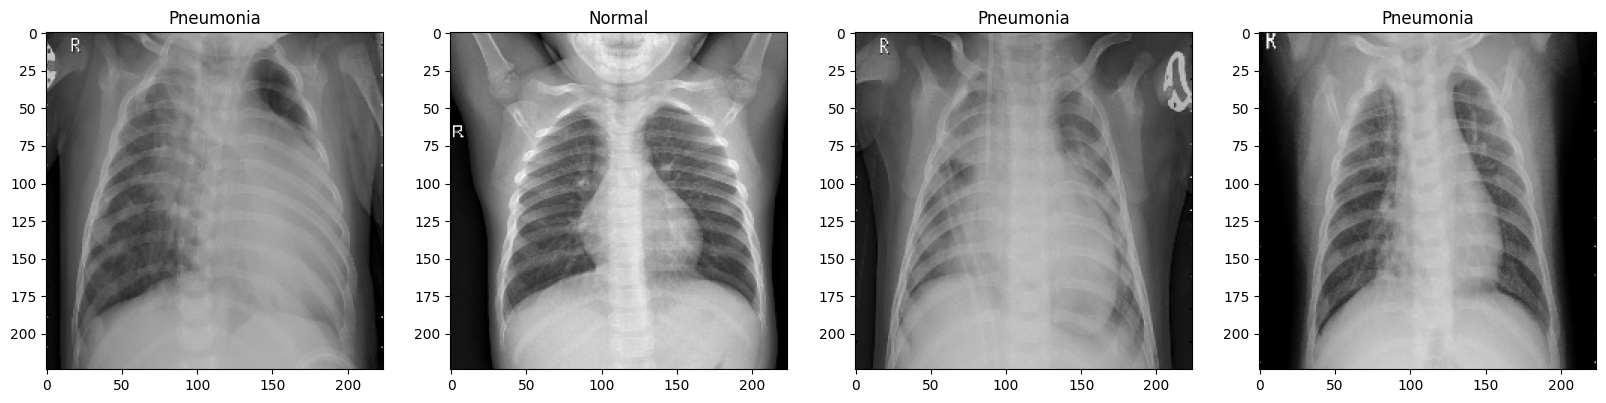

In [145]:
# Display some images from train set

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (y[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')

    plt.imshow(X[i])
    k=k+1

In [146]:
# get the labels for test set
P, t = preprocess_image(test_imgs)

In [147]:
arr=t
uniqueValues, occurCount = np.unique(arr, return_counts=True)

print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1]
Occurrence Count :  [237 641]


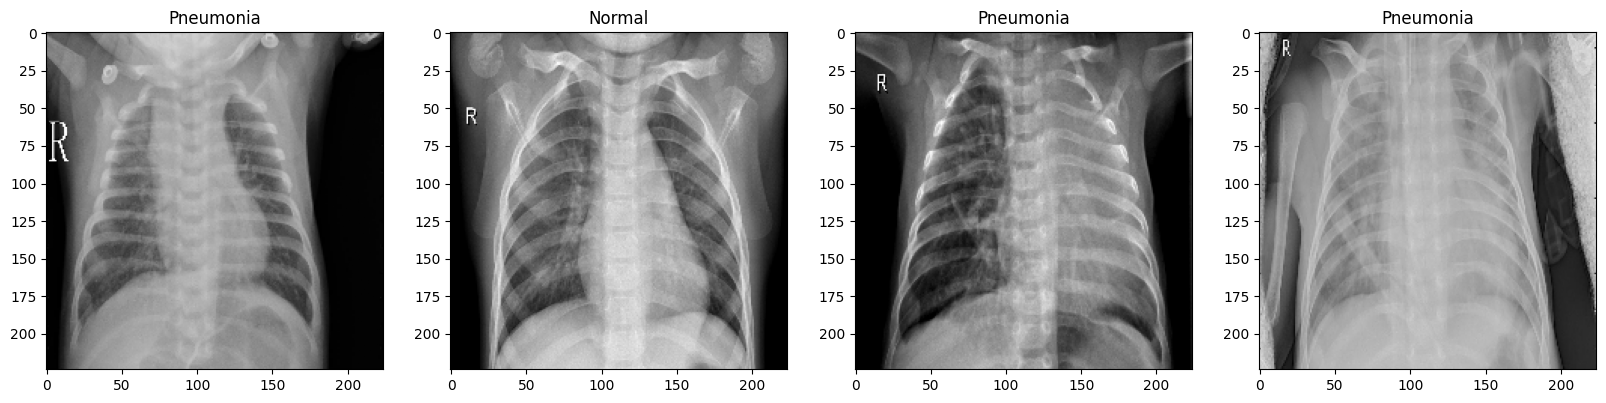

In [148]:
# now displaying some images from test set
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (t[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')

    plt.imshow(P[i])
    k=k+1

In [149]:
# get the labels for validation set

K, m = preprocess_image(val_imgs)

In [150]:
arr=m

# Get a tuple of unique values & their frequency in numpy array
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1]
Occurrence Count :  [ 79 214]


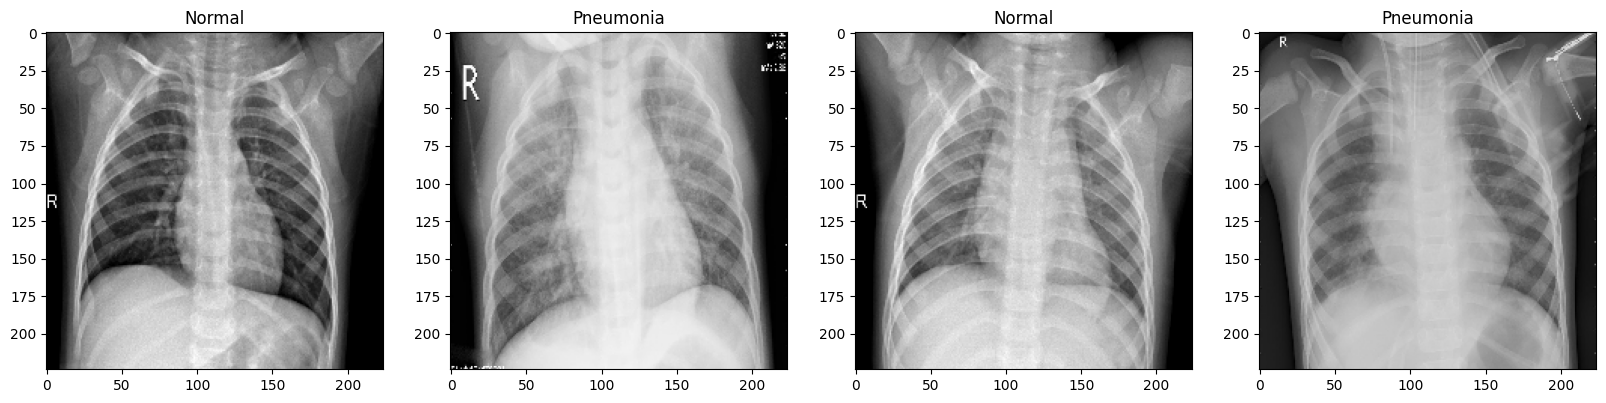

In [151]:
# now displaying some images from validation set
# Feel free to show more image by changing the values

import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (m[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
        
    plt.imshow(K[i])
    k=k+1;

/tmp/ipykernel_58/3860858750.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Train'], ax=ax[0], palette=['skyblue', 'orange'])
/tmp/ipykernel_58/3860858750.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Test'], ax=ax[1], palette=['skyblue', 'orange'])
/tmp/ipykernel_58/3860858750.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Val'], ax=ax[2], palette=['skyblue', 'orange'])


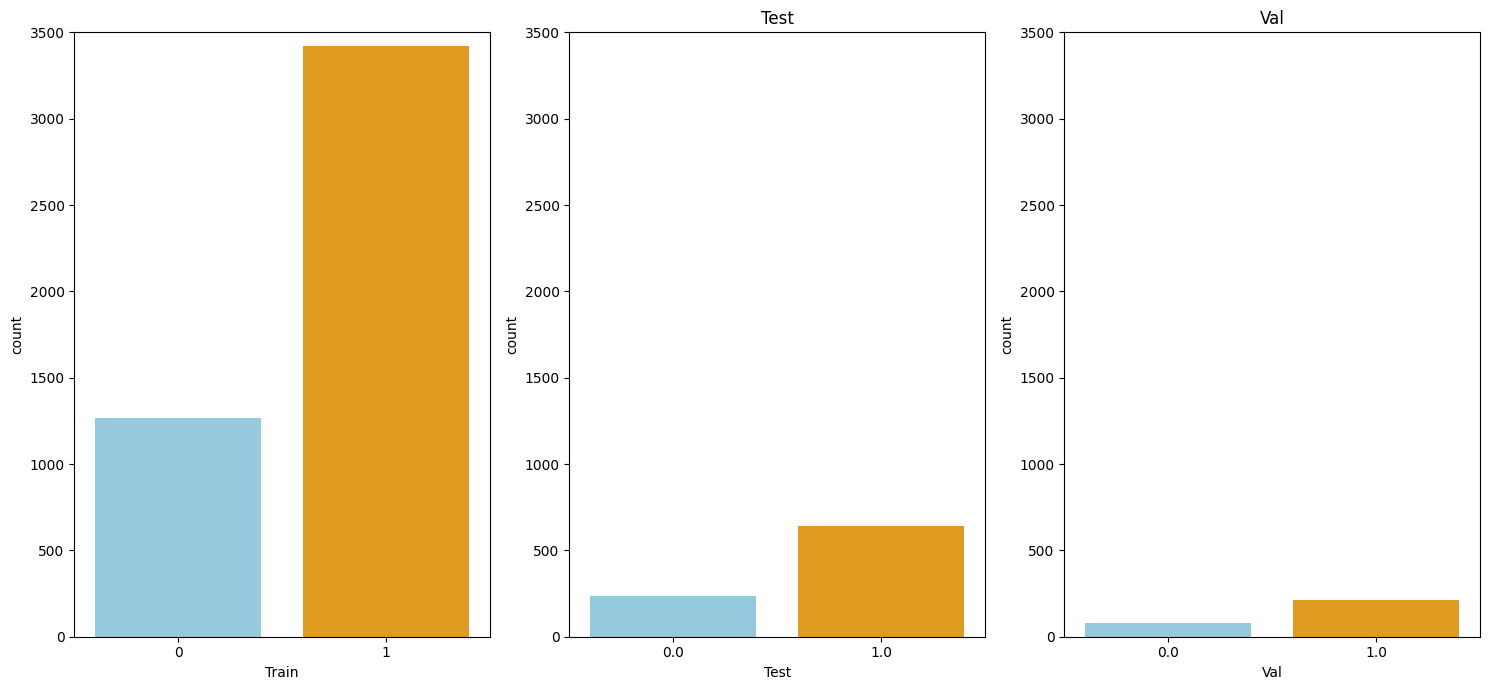

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame()
df['Train'] = y
df['Test'] = pd.Series(t)
df['Val'] = pd.Series(m)

fig, ax = plt.subplots(1, 3, figsize=(15, 7))

sns.countplot(x=df['Train'], ax=ax[0], palette=['skyblue', 'orange'])
ax[0].set_ylim(0, 3500)

sns.countplot(x=df['Test'], ax=ax[1], palette=['skyblue', 'orange'])
ax[1].set_title("Test")
ax[1].set_ylim(0, 3500)

sns.countplot(x=df['Val'], ax=ax[2], palette=['skyblue', 'orange'])
ax[2].set_title("Val")
ax[2].set_ylim(0, 3500)

plt.tight_layout()
plt.show()

In [153]:
#handles class imbalance, gives larger weight to the class with lesser data
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.8488555643251776), 1: np.float64(0.6853423054417788)}


In [154]:
#preparing the data for tensorflow
import seaborn as sns
import gc

del train_imgs
gc.collect()

X_train = np.array(X)
y_train = np.array(y)
X_test = np.array(P)
y_test = np.array(t)
X_val = np.array(K)
y_val = np.array(m)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)

(4685, 224, 224, 3)
(4685,)
(878, 224, 224, 3)
(878,)
(293, 224, 224, 3)
(293,)


In [155]:
del X #deletes orginal array of images to free memory as X_train, etc are created
del y #similar to del X
gc.collect() #saves RAM

#get the length of the train and validation data
ntrain = len(X_train)
nval = len(X_val)

batch_size = 32


In [156]:
import tensorflow as tf
print(tf.__version__)

#image data generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(  #data augmentation, reduces overfitting
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.2,
    zoom_range=0.45,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    zoom_range=0.45
)

2.19.0


In [157]:
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size) #connects X_train and y_train to the augmentation pipeline
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size) #does the same

In [158]:
# Set image Size
img_size =224

In [159]:
#Train full train set with MobileNet¶
#This cell creates a MobileNet-based CNN that takes a 224×224 chest X-ray image and outputs a probability that the image contains pneumonia, training the network from scratch using binary cross-entropy loss and the Adam optimizer.

from keras import layers
from keras import models
from keras import optimizers
from keras.applications import *
from keras.layers import Dense, GlobalAveragePooling2D
from keras.preprocessing.image import img_to_array, load_img
from keras.models import Model
from keras import backend as K

# Create the base pre-trained model
# Weights should be none becuase we don't need to train with any pre-trained weights here

base_model = MobileNet(weights=None, include_top=False,input_shape=(img_size, img_size, 3))

x = base_model.output #at this step the CNN has extracted features from the data

# Add a global spatial average pooling layer
x = GlobalAveragePooling2D()(x)

# Add a logistic layer
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions) #connect everythinig tgt

# Compile model
model.compile(optimizer='adam', loss = 'binary_crossentropy',
                           metrics = ['binary_accuracy', 'mae'])



In [160]:
print("Training Images:", X_train.shape[0])
history = model.fit(train_generator,
                    epochs=64,
                    validation_data=val_generator,
                    class_weight =class_weights,
)
     

Training Images: 4685
Epoch 1/64
 17/147 ━━━━━━━━━━━━━━━━━━━━ 36s 282ms/step - binary_accuracy: 0.6423 - loss: 0.7085 - mae: 0.4070

2026-06-10 08:43:04.506406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-10 08:43:04.705472: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


147/147 ━━━━━━━━━━━━━━━━━━━━ 88s 453ms/step - binary_accuracy: 0.8248 - loss: 0.3971 - mae: 0.2272 - val_binary_accuracy: 0.7304 - val_loss: 1.1629 - val_mae: 0.2760
Epoch 2/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 46s 314ms/step - binary_accuracy: 0.8617 - loss: 0.3223 - mae: 0.1846 - val_binary_accuracy: 0.7304 - val_loss: 1.3730 - val_mae: 0.2725
Epoch 3/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 46s 316ms/step - binary_accuracy: 0.8645 - loss: 0.3117 - mae: 0.1807 - val_binary_accuracy: 0.7304 - val_loss: 1.6721 - val_mae: 0.2706
Epoch 4/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 47s 316ms/step - binary_accuracy: 0.8800 - loss: 0.2704 - mae: 0.1587 - val_binary_accuracy: 0.7304 - val_loss: 2.5370 - val_mae: 0.2696
Epoch 5/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 48s 323ms/step - binary_accuracy: 0.8950 - loss: 0.2599 - mae: 0.1487 - val_binary_accuracy: 0.8703 - val_loss: 0.2836 - val_mae: 0.1463
Epoch 6/64
147/147 ━━━━━━━━━━━━━━━━━━━━ 47s 318ms/step - binary_accuracy: 0.8939 - loss: 0.2583 - mae: 0.1524 - val_binary_acc

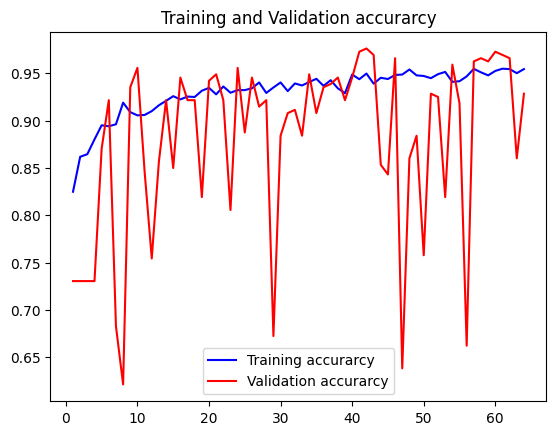

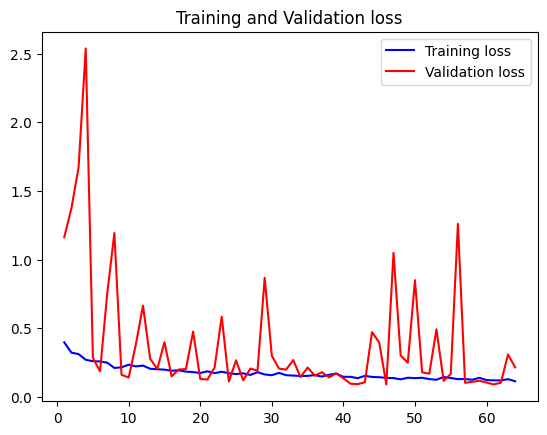

In [161]:
# Lets plot the train and val curve
# Get the details form the history object
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accurarcy')
plt.plot(epochs, val_acc, 'r', label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

In [162]:
from sklearn.metrics import accuracy_score, confusion_matrix

preds = model.predict(X_test)

acc = accuracy_score(y_test, np.round(preds))*100
cm = confusion_matrix(y_test, np.round(preds))

tn, fp, fn, tp = cm.ravel()

print('CONFUSION MATRIX ------------------')
print(cm)

print('\n============TEST METRICS=============')
precision = tp/(tp+fp)*100
recall = tp/(tp+fn)*100
print('Accuracy: {}%'.format(acc))
print('Precision: {}%'.format(precision))
print('Recall: {}%'.format(recall))
print('F1-score: {}'.format(2*precision*recall/(precision+recall)))

print('\nTRAIN METRIC ----------------------')
print('Train acc: {}'.format(np.round((history.history['binary_accuracy'][-1])*100, 2)))


28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step
CONFUSION MATRIX ------------------
[[210  27]
 [ 26 615]]

============TEST METRICS=============
Accuracy: 93.96355353075171%
Precision: 95.7943925233645%
Recall: 95.94383775351014%
F1-score: 95.86905689789556

TRAIN METRIC ----------------------
Train acc: 95.43


<Axes: >

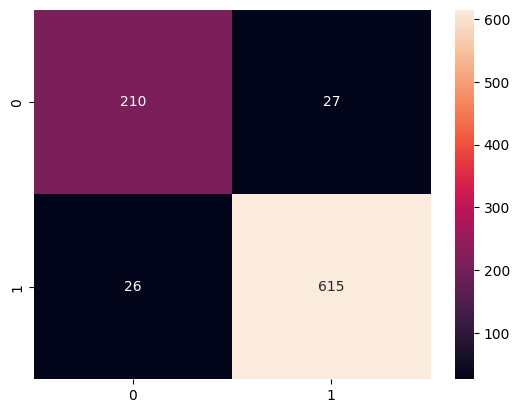

In [163]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d",)

AUC Score: 0.9870060625209819


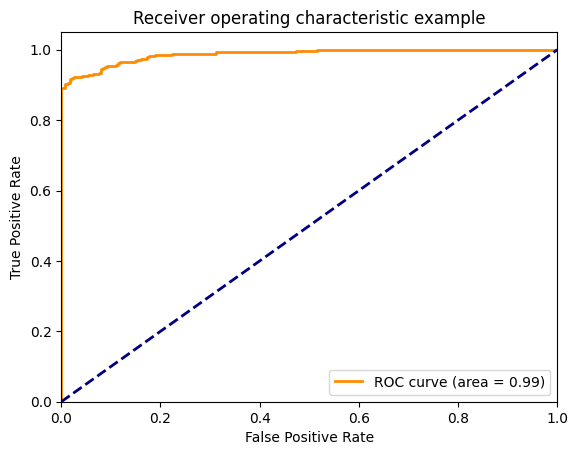

In [164]:
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.metrics import auc

fpr , tpr , thresholds = roc_curve ( y_test , preds)
auc_keras = auc(fpr, tpr)
print("AUC Score:",auc_keras)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % auc_keras)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [165]:
#final training and validation
print("Final Validation Accuracy :", history.history['val_binary_accuracy'][-1])
print("Final Training Loss :", history.history['loss'][-1])
print("Final Validation Loss :", history.history['val_loss'][-1])

#best validation accuracy
import numpy as np

best_epoch_acc = np.argmax(history.history['val_binary_accuracy']) + 1
best_val_acc = np.max(history.history['val_binary_accuracy'])

print("Best Epoch:", best_epoch_acc)
print("Best Validation Accuracy:", best_val_acc)

#lowest validation loss
best_epoch_loss = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])

print("Best Epoch:", best_epoch_loss)
print("Lowest Validation Loss:", best_val_loss)



Final Validation Accuracy : 0.9283276200294495
Final Training Loss : 0.11387315392494202
Final Validation Loss : 0.21491122245788574
Best Epoch: 42
Best Validation Accuracy: 0.9761092066764832
Best Epoch: 46
Lowest Validation Loss: 0.09049850702285767


In [166]:
test_loss, test_acc, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - binary_accuracy: 0.9396 - loss: 0.1449 - mae: 0.0703
Test Accuracy: 0.9396355152130127
Test Loss: 0.14494553208351135
Test MAE: 0.07025904953479767
